In [8]:
import ast
import json
import re
import requests

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from bootcampviztools import plot_grouped_histograms
from toolbox_ML_v2 import describe_df, tipifica_variables

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import  KNeighborsRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import cross_val_score


from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features
import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|') 

# Extracción de datos

In [9]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df])
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/rivas-vaciamadrid/637551.html


# Train test split

In [10]:
X = df.drop(columns='precio')
y = df['precio'].replace(' €', '', regex=True).apply(ast.literal_eval).apply(lambda x: x.get('price')).str.replace('.', '').astype(int)
y.describe() 

count    1.219000e+03
mean     2.983957e+05
std      1.841536e+05
min      4.490000e+04
25%      1.920000e+05
50%      2.500000e+05
75%      3.375000e+05
max      1.950000e+06
Name: precio, dtype: float64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(975, 11)
(244, 11)
(975,)
(244,)


# Pretratamiento de datos

In [12]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [13]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:248: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [14]:
X_train_limpio.head()

,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord
978,3.0,87.0,1.0,41.063102,-2.642883,2.0,None,0,Independiente,1999,0,0,28,145.0,40.0,2,380.0,3,200.0,2,470.0,0,NaN,4,320.0,5,290.0,5,410.0,5,130.0,1,0,1,2.0
277,NaN,60.0,NaN,40.381802,-3.665822,NaN,None,0,None,1980,0,0,0,NaN,NaN,5,110.0,5,380.0,5,50.0,1,2900.0,5,180.0,5,1200.0,5,440.0,5,270.0,0,0,0,NaN
722,3.0,100.0,2.0,40.381500,-3.621360,1.0,Independiente,1,Independiente,2025,0,0,30,NaN,NaN,5,160.0,5,330.0,5,180.0,2,180.0,5,240.0,5,340.0,5,390.0,5,50.0,1,0,0,NaN
602,2.0,55.0,1.0,40.378502,-3.747162,3.0,Independiente,1,Independiente,1964,0,0,20,164.0,33.0,5,60.0,5,100.0,5,60.0,5,1100.0,5,150.0,5,150.0,5,140.0,5,170.0,1,0,0,2.0
679,3.0,75.0,1.0,40.436202,-3.647113,1.0,None,0,Independiente,1957,1,0,24,175.0,36.0,4,80.0,5,80.0,5,80.0,5,660.0,5,320.0,5,190.0,5,290.0,5,240.0,1,0,0,2.0


# MiniEDA

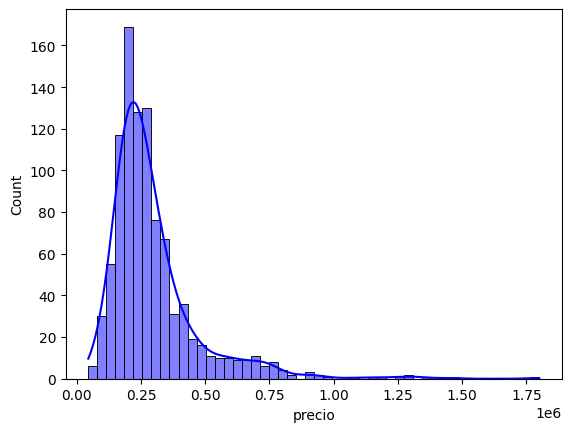

In [15]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [16]:
X_train_limpio.shape

(975, 35)

In [17]:
describe_df(X_train_limpio).T[['Cardinalidad','Clasificacion_sugerida']]

Clasificación sugerida para 975 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


Columnas,Cardinalidad,Clasificacion_sugerida
dormitorios,6,Categorica
superficie_m2,161,Numerica_Continua
baños,4,Categorica
latitud,839,Numerica_Continua
longitud,955,Numerica_Continua
planta,13,Numerica_Discreta
aire_acondicionado,3,Categorica
ascensor,2,Categorica_Binaria
calefaccion,3,Categorica
ano_construccion,97,Numerica_Discreta


In [37]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categoricas = tipifica_variables(X_train_limpio)['Categorica']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

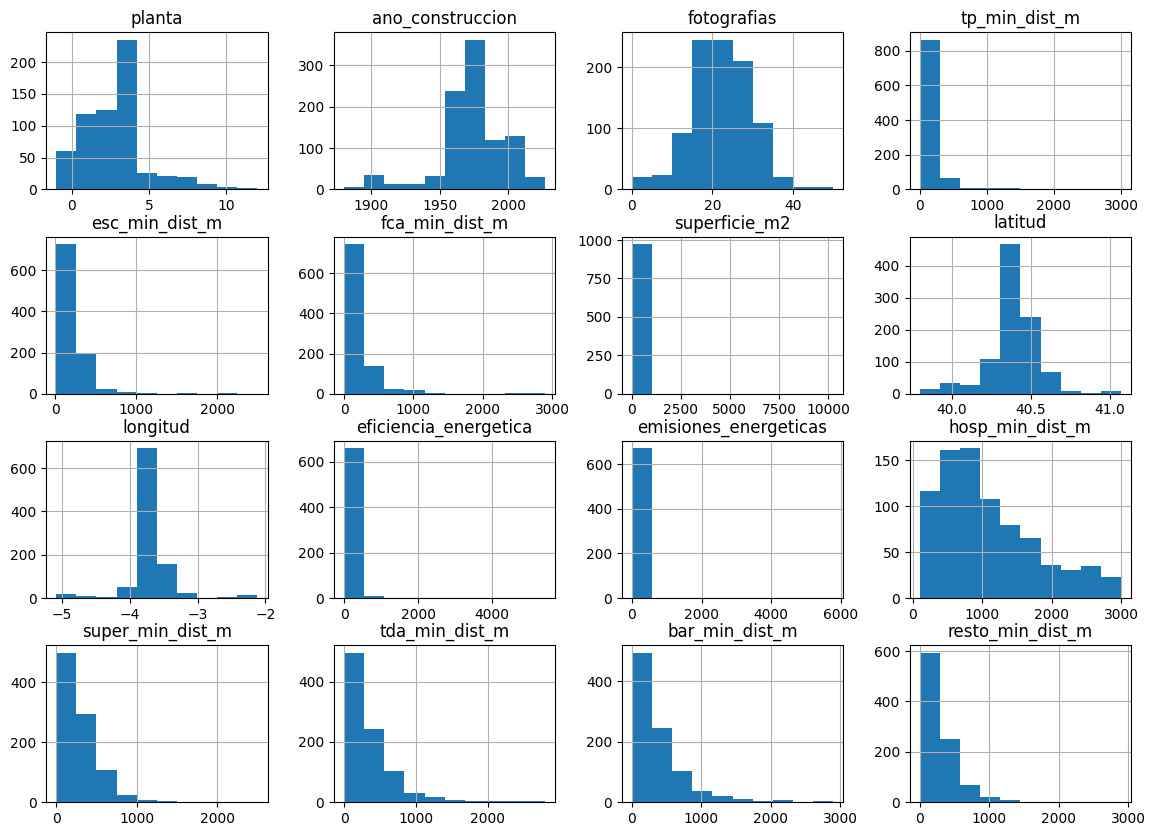

In [19]:
X_train_limpio[numericas].hist(figsize=(14, 10));

In [41]:
train_set = X_train_limpio.copy()
train_set['Precio'] = y_train.values  
target = 'Precio'
train_set

,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,Precio
978,3.0,87.0,1.0,41.063102,-2.642883,2.0,None,0,Independiente,1999,0,0,28,145.0,40.0,2,380.0,3,200.0,2,470.0,0,NaN,4,320.0,5,290.0,5,410.0,5,130.0,1,0,1,2.0,95000
277,NaN,60.0,NaN,40.381802,-3.665822,NaN,None,0,None,1980,0,0,0,NaN,NaN,5,110.0,5,380.0,5,50.0,1,2900.0,5,180.0,5,1200.0,5,440.0,5,270.0,0,0,0,NaN,219000
722,3.0,100.0,2.0,40.381500,-3.621360,1.0,Independiente,1,Independiente,2025,0,0,30,NaN,NaN,5,160.0,5,330.0,5,180.0,2,180.0,5,240.0,5,340.0,5,390.0,5,50.0,1,0,0,NaN,334000
602,2.0,55.0,1.0,40.378502,-3.747162,3.0,Independiente,1,Independiente,1964,0,0,20,164.0,33.0,5,60.0,5,100.0,5,60.0,5,1100.0,5,150.0,5,150.0,5,140.0,5,170.0,1,0,0,2.0,220000
679,3.0,75.0,1.0,40.436202,-3.647113,1.0,None,0,Independiente,1957,1,0,24,175.0,36.0,4,80.0,5,80.0,5,80.0,5,660.0,5,320.0,5,190.0,5,290.0,5,240.0,1,0,0,2.0,339000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,4.0,123.0,2.0,40.491302,-3.378653,3.0,Independiente,0,None,1979,0,0,30,201.0,42.0,4,80.0,5,130.0,5,510.0,4,1400.0,5,400.0,5,470.0,5,1200.0,5,210.0,0,0,1,2.0,310000
1095,4.0,120.0,2.0,40.321902,-3.854322,NaN,Independiente,1,centralizada,1975,0,0,29,NaN,NaN,5,150.0,5,210.0,5,60.0,5,990.0,5,300.0,5,530.0,5,710.0,5,550.0,0,0,1,NaN,319900
1130,2.0,45.0,1.0,40.412802,-3.718972,-1.0,None,0,None,1915,0,0,22,NaN,NaN,5,90.0,5,220.0,5,110.0,5,350.0,5,200.0,5,170.0,5,20.0,5,50.0,0,0,3,NaN,209000
860,1.0,45.0,1.0,40.463800,-3.476840,1.0,None,0,None,1970,0,0,10,NaN,NaN,4,300.0,5,50.0,5,140.0,4,300.0,5,180.0,5,110.0,5,280.0,5,70.0,0,0,1,NaN,170000


#### Analisis bivariante

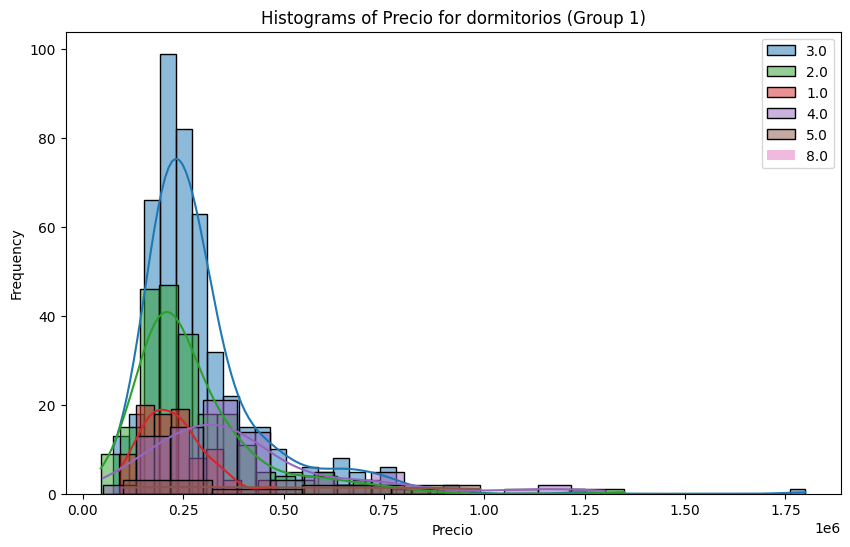

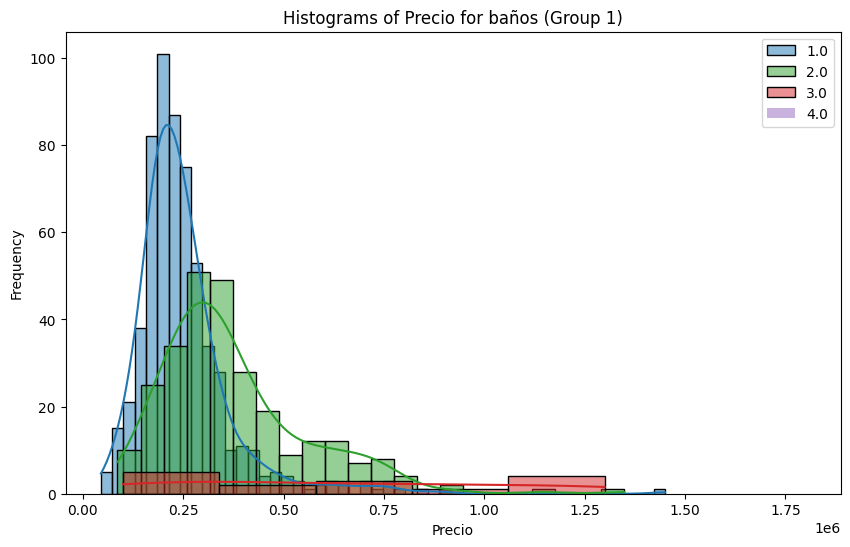

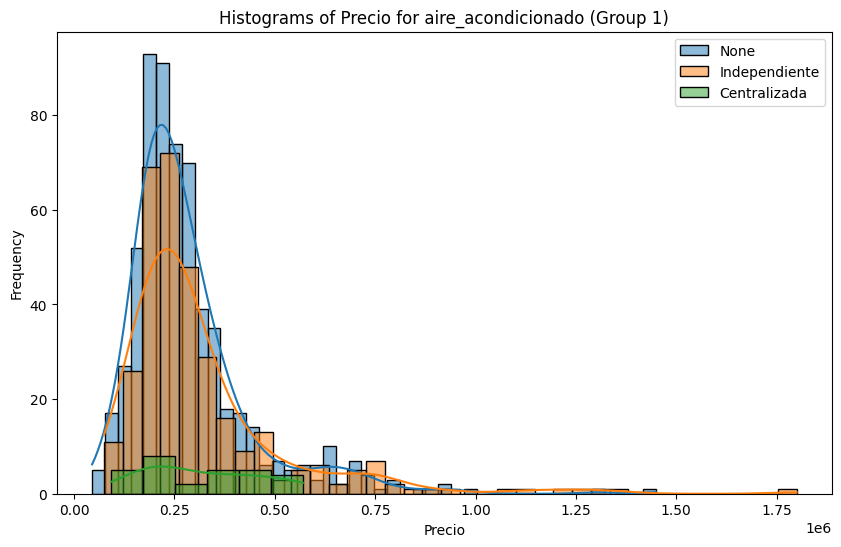

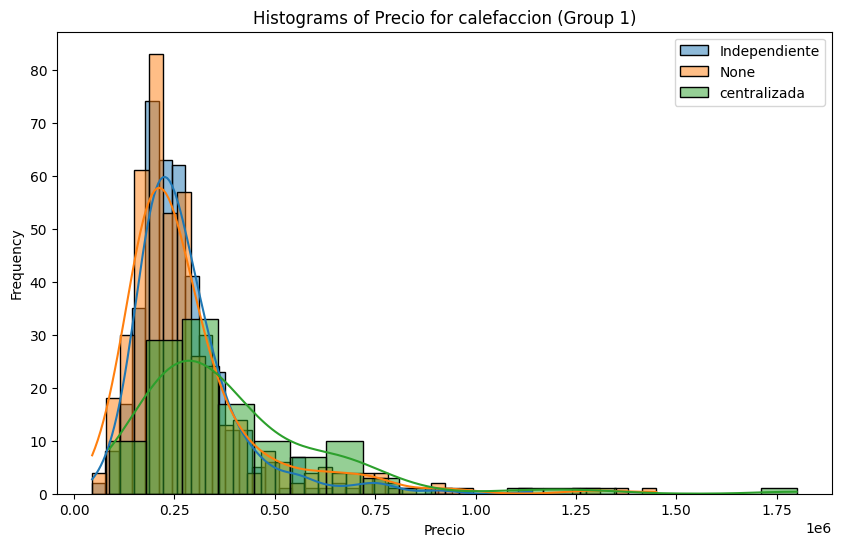

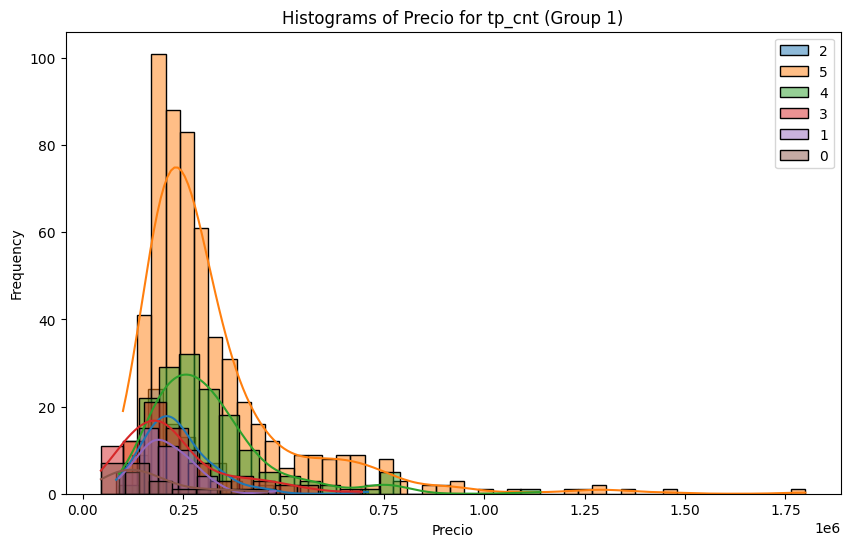

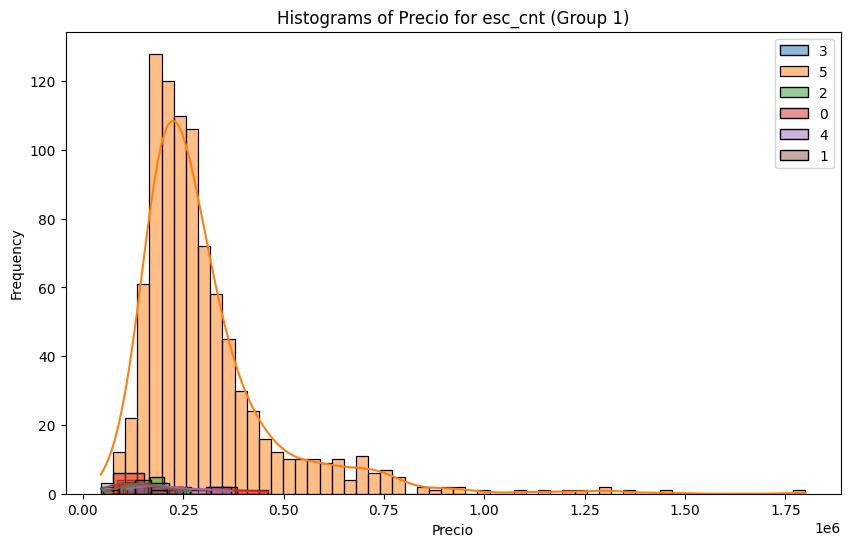

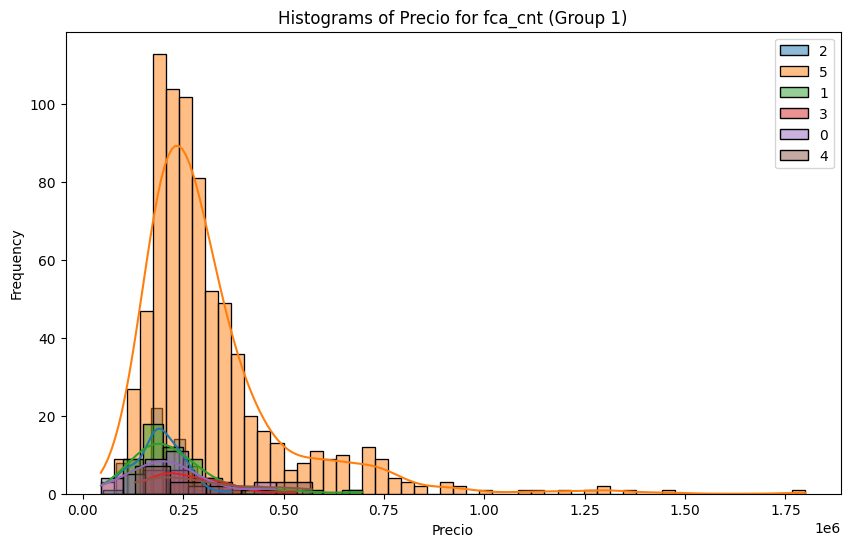

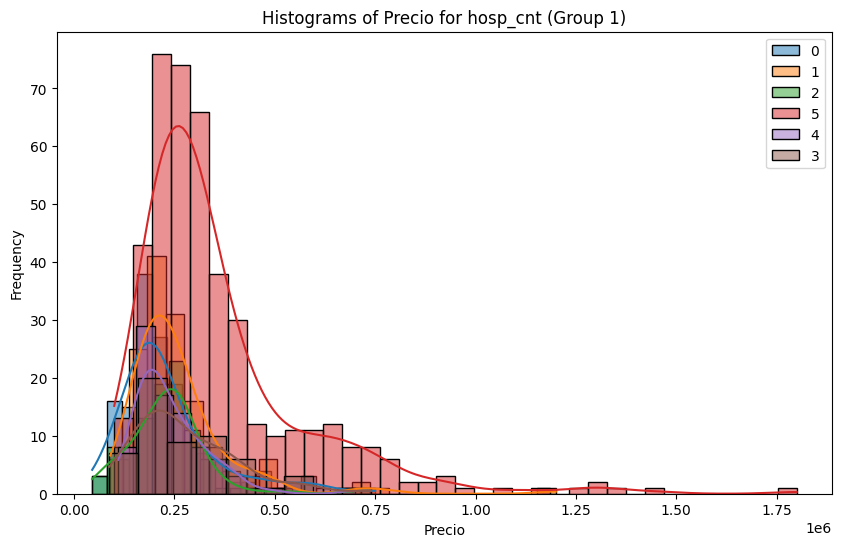

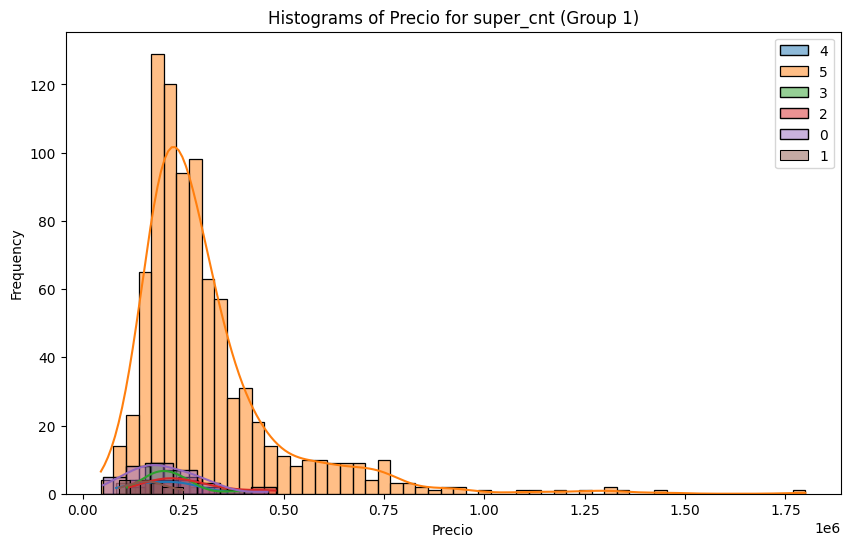

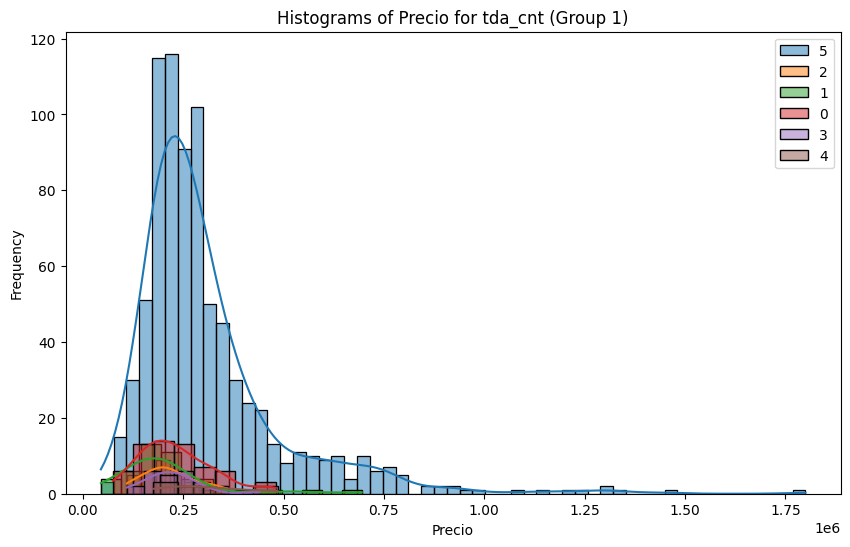

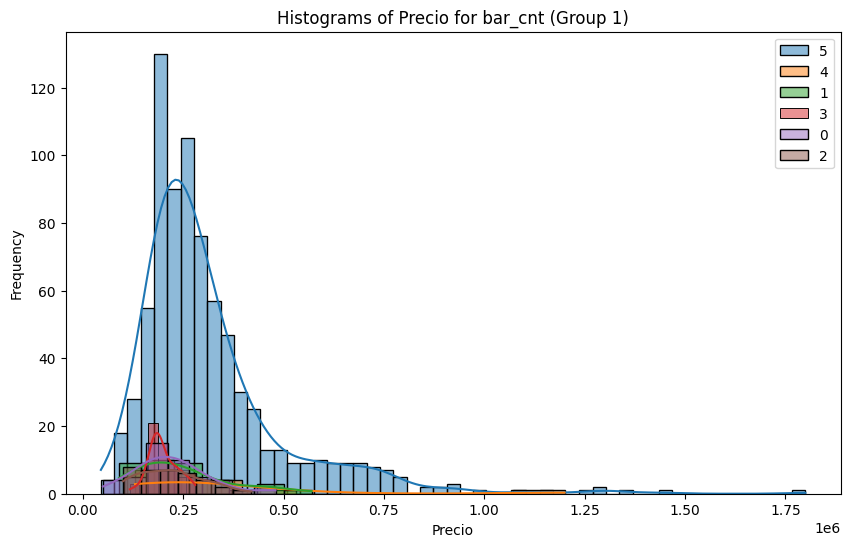

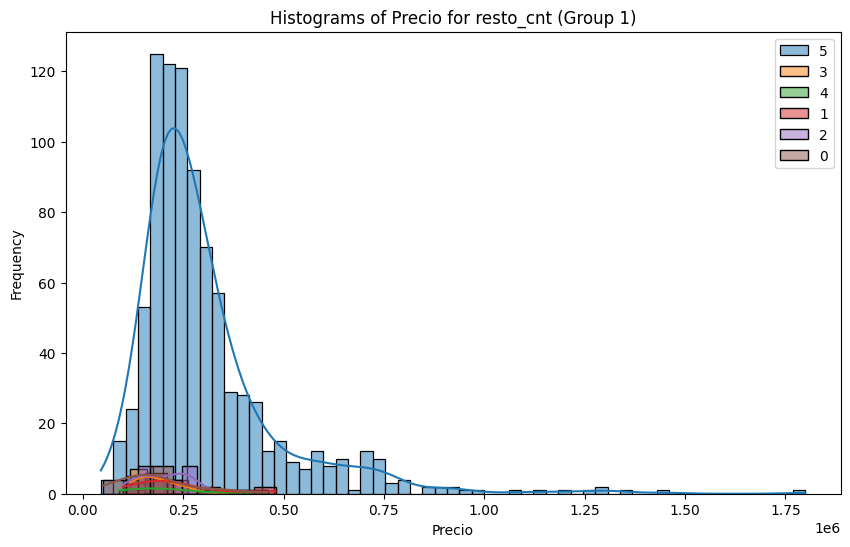

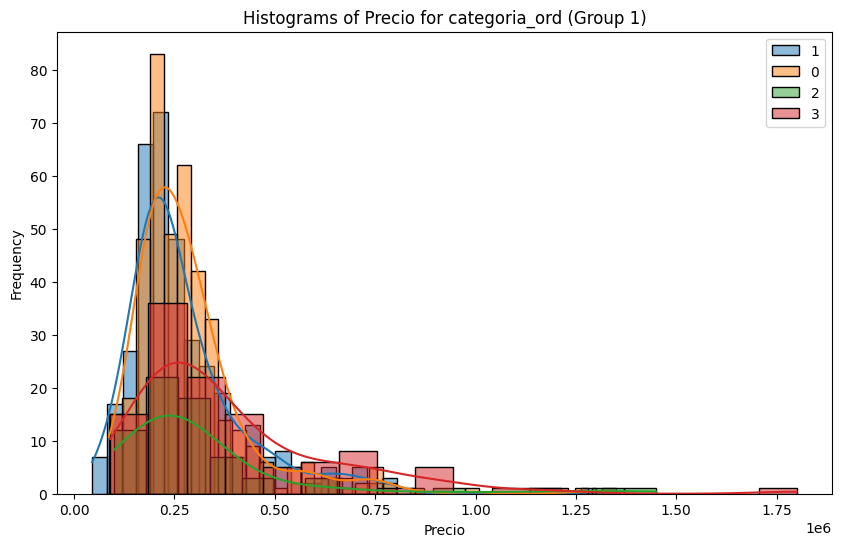

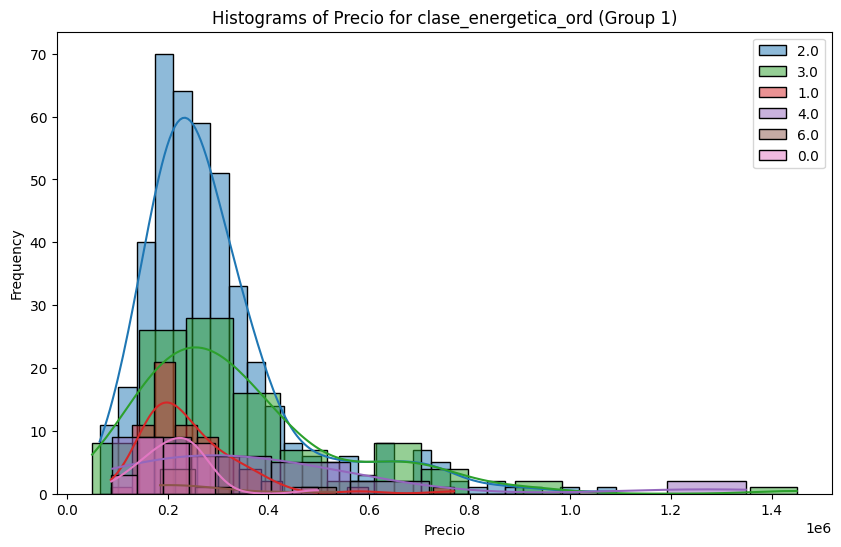

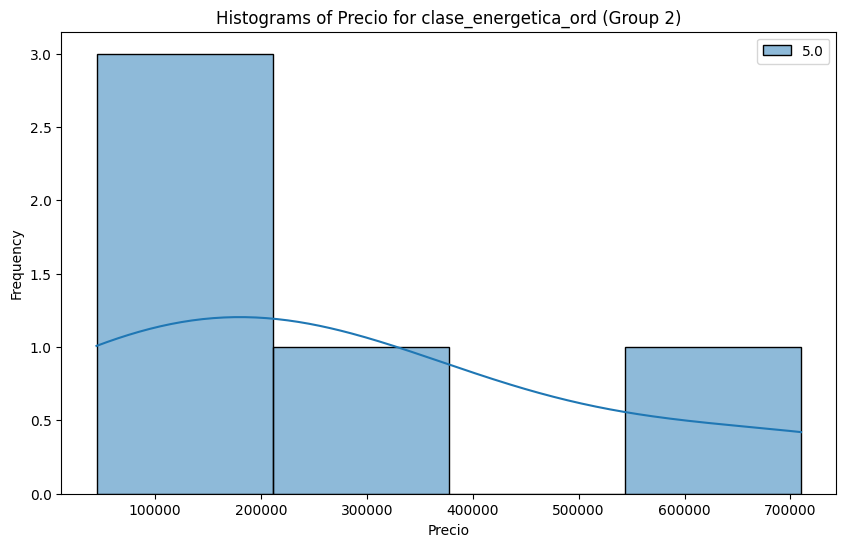

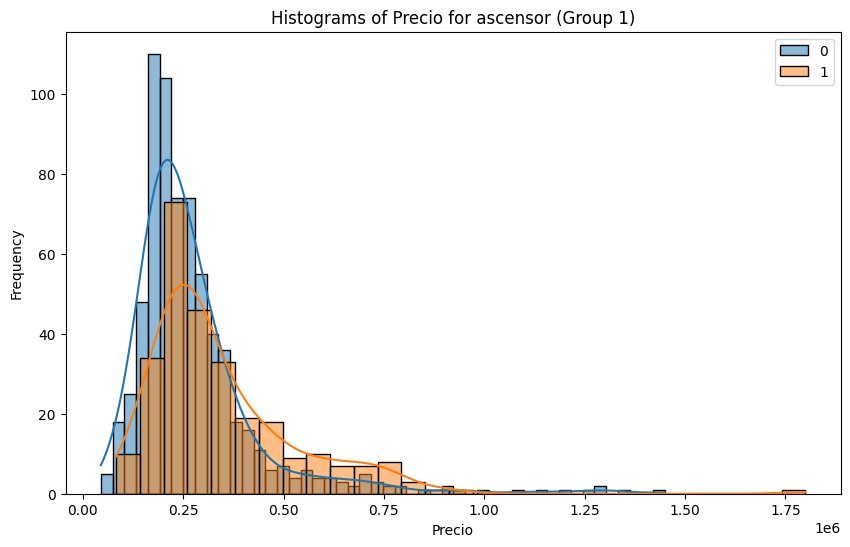

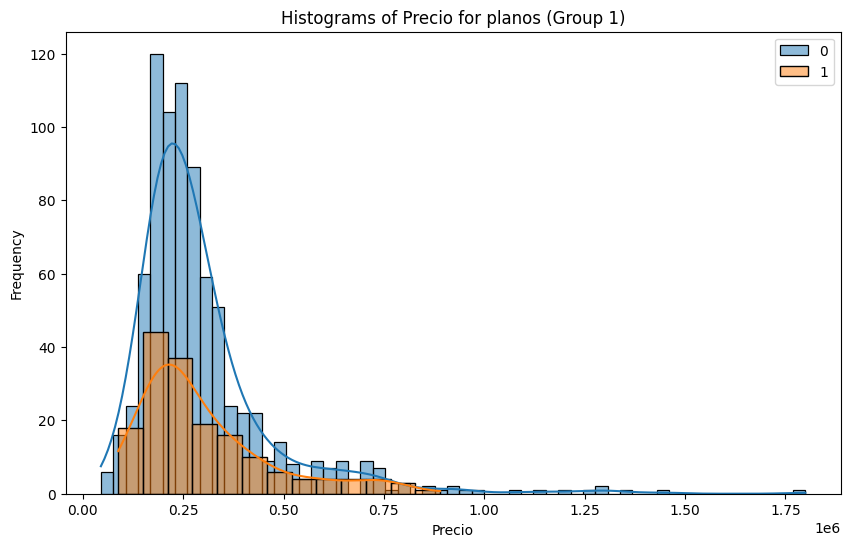

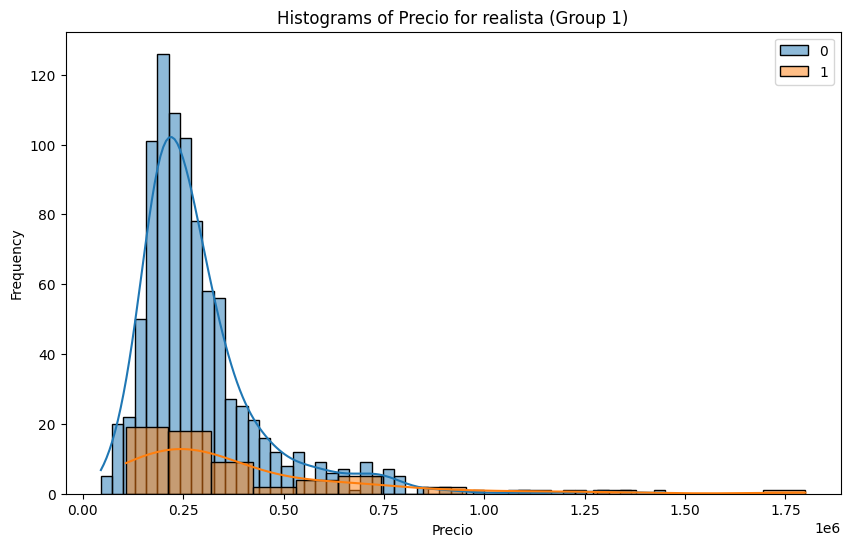

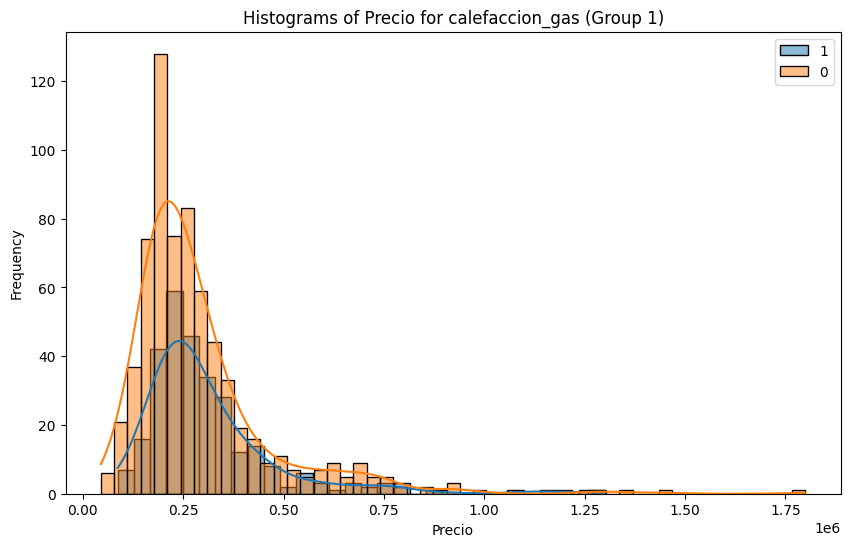

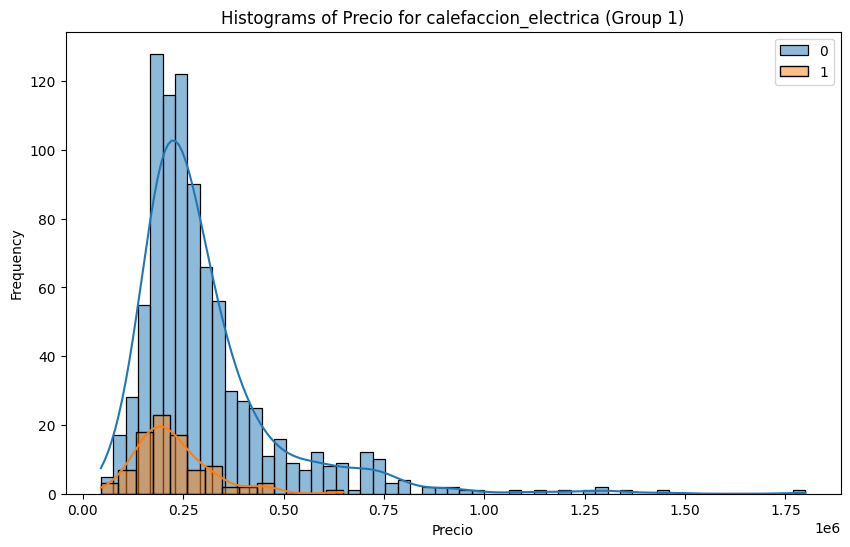

In [22]:

for col in (categoricas + binaria):
    if col in train_set.columns:
        bt.plot_grouped_histograms(train_set, cat_col=col, num_col='Precio', group_size = 7 )
    else:
        print(f'[WARN] {col} no está en df_plot.columns')

* **Precio por dormitorios:** los grupos más frecuentes son 3, 2, 1 y 4 dormitorios, y entre 1–3 se comportan de forma bastante similar. El de **4 dormitorios** sí se nota con un precio más alto.  
* **Baños:** lo más claro es 1, 2 y 3 baños; los histogramas se desplazan hacia la derecha a medida que aumenta la cantidad de baños.  
* **Aire acondicionado:** no vemos mucha diferencia en el comportamiento entre categorías (no tiene / independiente / centralizada). No se observan cruces especialmente evidentes.  
* **Calefacción:** se ve levemente un desplazamiento hacia la derecha (aumento del precio). Sin calefacción: menor precio; luego un poco más con calefacción independiente; y apenas un poco más con centralizada.  

* **Puntos de interés (servicios cercanos):**  
  1) **Transporte público:** lo interesante es que los que **no tienen transporte público cerca** se desplazan hacia la izquierda (más baratos). Si ordeno los histogramas de izquierda a derecha, se ve: **0, 3, 1, 2, 4/5**.  
  2) **Escuelas:** la mayoría tiene **5 alrededor**, por lo que domina el histograma y no se aprecia un patrón claro.  
  3) **Farmacias:** si bien la mayoría tiene **5**, los histogramas se cruzan mucho y no hay un orden definido. Por ejemplo, tener **1 farmacia** parece asociarse a mayor precio que tener **2 farmacias**.  
  4) **Hospitales:** de mucho interés; se entrecruzan todos los histogramas y se ve un desplazamiento hacia la derecha en los que tienen **5 hospitales alrededor**.  
  5) **Supermercados:** aunque la mayoría tiene **5**, se observa que los histogramas se entrecruzan bastante.  
  6) **Tiendas:** se entrelazan mejor que el resto.  
  7) **Bares:** los más corridos a la derecha son los que tienen **0, 1 y 2**.  
  8) **Restaurantes:** se ve, levemente, un desplazamiento hacia la izquierda en quienes no tienen restaurantes; los histogramas se entrecruzan.  

* **categoria_ord:** se ve que los outliers son de la **categoría 3**. La 3 y la 2 se entrecruzan en precios más altos; la 1 muestra precios más bajos. Luego aparecen más casos en 0 y 2, y finalmente en 3.  
* **clase_energetica_ord:** se observa claramente que los histogramas se entrelazan. Diría que los precios más altos serían los de la **clase 3**.  

**Target y variables binarias:**  
* **Ascensor:** de interés; con ascensor parecen levemente más caros.  
* **Planos:** podría sacarse; no se ven comportamientos distintos del target.  
* **Realista:** tampoco se ven cambios si tiene o no; se podría sacar.  
* **Calefacción gas:** no se ven comportamientos distintos; la sacaría.  
* **Calefacción eléctrica:** igual, sin comportamiento claro.  


En estos gráficos estuve mirando cómo se mueve el precio según distintas variables. En general, el target está muy sesgado a la derecha (cola larga con outliers), así que muchas categorías se pisan bastante y a veces cuesta ver diferencias claras solo con histogramas superpuestos. Aun así, hay algunas cosas que se repiten y otras que me dejan dudas (más por mezcla de zonas/tamaño de muestra que por falta de señal).

#### 1) Variables “de la vivienda” (más directas)

- **Dormitorios:** los grupos con más presencia son 1, 2, 3 y 4.  
  - Entre **1–3** se ven bastante parecidos y se superponen mucho.  
  - El que sí se nota más corrido a la derecha es **4 dormitorios**, que en promedio parece asociarse a precios más altos.  
  - Igual, esto puede estar muy influido por **superficie**: un piso con 4 dormitorios suele ser más grande, entonces parte del “efecto dormitorios” probablemente sea “efecto m²”.

- **Baños:** acá la relación es más clara.  
  - Con más baños el histograma se corre hacia la derecha.  
  - En especial, **1 vs 2 baños** muestra un cambio bastante evidente.  
  - Con **3 baños** también se ve un escalón hacia precios mayores (aunque con menos casos).

#### 2) Confort / instalaciones (señal leve, pero algo se ve)

- **Aire acondicionado:** no me queda una diferencia fuerte entre “no tiene / independiente / centralizada”.  
  - Los histogramas se cruzan bastante y el patrón no se marca tanto.  
  - Para mí es una variable que podría aportar algo en un modelo, pero a ojo no es de las más discriminantes en estos gráficos.

- **Calefacción:** acá sí se insinúa un gradiente.  
  - “Sin calefacción” tiende a estar más a la izquierda.  
  - Luego “independiente” y “centralizada” parecen moverse un poco hacia la derecha.  
  - No es un salto enorme, pero algo hay, aunque con bastante solapamiento.

#### 3) Variables de entorno (servicios cercanos)

Estas son las que más me cuesta interpretar en forma “causal”, porque probablemente estén capturando **centralidad/zona**. O sea, no es solo “más cosas cerca = más caro”, sino que “zonas más céntricas” suelen tener más servicios y a la vez ser más caras. Además, muchas variables están **capadas en 5** (la mayoría queda en “5”), y eso también hace que visualmente una categoría “se coma” a las otras.

- **Transporte público (tp_cnt):** esto sí me pareció interesante.  
  - Cuando es **0**, el precio se desplaza más a la izquierda (más barato).  
  - A medida que sube el conteo se ve más mezcla, y el orden fino (1 vs 2 vs 3 vs 4/5) no lo tomaría como conclusión fuerte solo por estos histogramas.

- **Escuelas (esc_cnt):** casi todo está en **5**, entonces no me permite diferenciar bien; parece una variable con poca capacidad discriminativa así como está.

- **Farmacias (fca_cnt):** hay mucho cruce y no veo un orden claro.  
  - Por ejemplo, tener 1 farmacia parece más caro que 2 en algunos rangos, lo cual me sugiere que acá hay bastante ruido o confusión por zona.

- **Hospitales (hosp_cnt):** me llamó la atención que el grupo con valores altos (sobre todo **5**) parece más corrido a la derecha.  
  - Puede ser señal real, pero también puede ser simplemente un proxy de barrios más céntricos o mejor conectados.

- **Supermercados / tiendas / restaurantes:** se entrecruzan bastante.  
  - En restaurantes sí se ve algo como que “0” podría estar un poco más a la izquierda, pero no es súper limpio.

- **Bares:** acá me sorprendió que los que tienen **0–2** parezcan más a la derecha.  
  - Esto puede ser real (zonas residenciales premium con menos oferta) o puede ser un artefacto por tamaños muestrales / mezcla por distrito, así que lo dejaría como “dato a confirmar”.

#### 4) Variables ordinales / categorizaciones

- **categoria_ord:** se ven outliers sobre todo en categoría 3.  
  - También se cruzan bastante 2 y 3 en precios altos, y 1 parece tender a precios más bajos.  
  - Pero no lo tomaría literal como “orden” si la codificación no representa una escala real.

- **clase_energetica_ord:** los histogramas se superponen mucho.  
  - Si tuviera que decir algo, es que no aparece un patrón fuerte.  
  - Los precios altos parecen aparecer en varias clases, y el grupo “3” se ve con algunos valores altos, pero no es una relación limpia.

#### 5) Binarias contra el target

- **Ascensor:** es de las más interesantes.  
  - Con ascensor parece haber un corrimiento leve a mayor precio.  
  - Igual, sospecho que se vería mejor si lo cruzo con planta (porque en pisos altos el ascensor pesa mucho más).

- **Planos:** no veo una diferencia clara; en estos gráficos no parece aportar demasiado.

- **Realista:** no noto cambio relevante.

- **Calefacción gas / eléctrica:** en estos histogramas no se ve un comportamiento distinto claro.  
  - Si tuviera que simplificar el set de variables, estas serían candidatas a recodificar o incluso quitar (dependiendo de si aportan algo en validación).

### Conclusión general

En resumen, lo que más consistente aparece es lo “estructural” (**baños y dormitorios**) y luego algunas cosas de confort (**calefacción y algo de ascensor**). Las variables de entorno son más difíciles de leer solo con histogramas porque se mezclan con la zona y muchas están dominadas por el valor 5, así que más que descartarlas por esto, lo que haría es confirmarlas con una **tabla de medianas por categoría** (y idealmente mirando **log(precio)** o **precio/m²**) para no dejarme llevar por el efecto de outliers y tamaños muestrales.

### Matriz de correlacion 

In [43]:
numericas_con_precio = ['planta','ano_construccion','fotografias','tp_min_dist_m', 'esc_min_dist_m','fca_min_dist_m','superficie_m2','latitud','longitud','eficiencia_energetica',
             'emisiones_energeticas','hosp_min_dist_m','super_min_dist_m','tda_min_dist_m','bar_min_dist_m','resto_min_dist_m','Precio']
corr = train_set[numericas_con_precio].corr()
np.abs(corr[target]).sort_values(ascending = False)

Precio                   1.000000
fotografias              0.216321
latitud                  0.215317
resto_min_dist_m         0.158277
tp_min_dist_m            0.142491
planta                   0.141730
hosp_min_dist_m          0.136367
tda_min_dist_m           0.119278
eficiencia_energetica    0.092912
fca_min_dist_m           0.090017
super_min_dist_m         0.084019
emisiones_energeticas    0.073485
bar_min_dist_m           0.072784
esc_min_dist_m           0.049697
superficie_m2            0.038422
ano_construccion         0.018489
longitud                 0.018156
Name: Precio, dtype: float64

<Axes: >

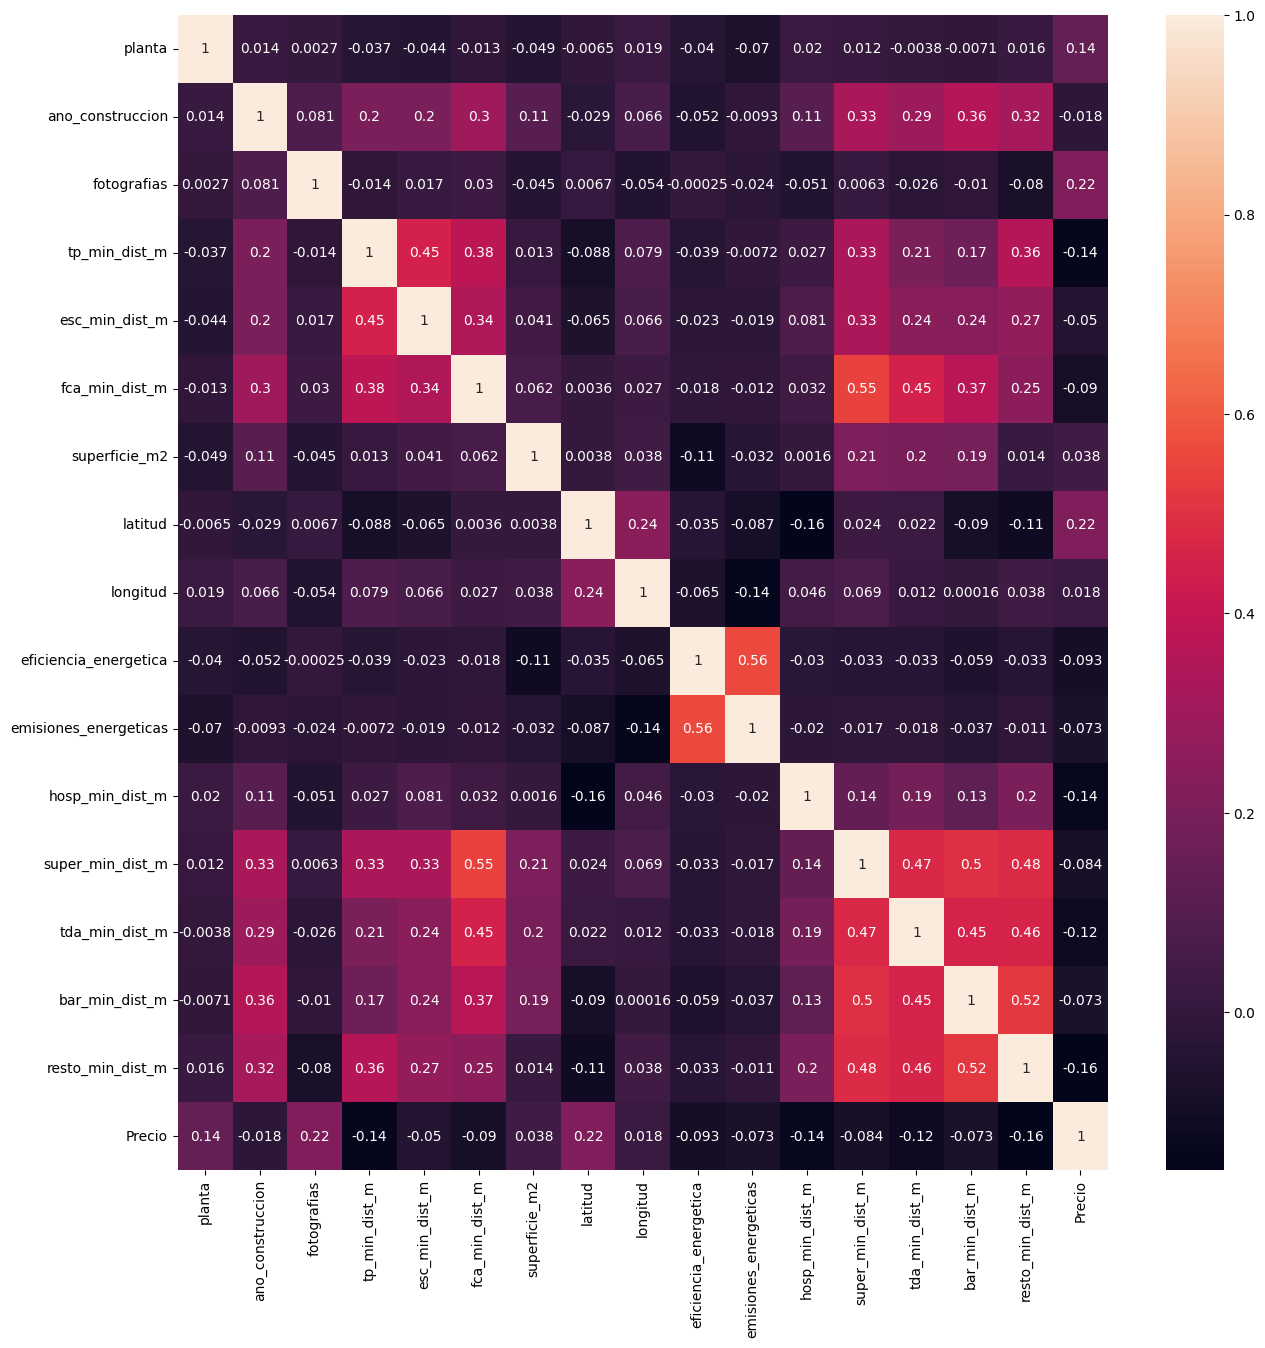

In [ ]:
plt.figure(figsize = (15,15))
sns.heatmap(corr, annot= True)

### 1) Correlación absoluta con el target (Precio):
A partir del ranking de correlaciones absolutas con **Precio**, se observa que las correlaciones son, en general, **bajas** (las más altas rondan aproximadamente **0.22** y el resto cae por debajo). Esto sugiere que **no hay relaciones lineales fuertes** entre el precio y estas variables numéricas consideradas de forma individual.

Esto **no implica** que las variables “no sirvan”, sino que:
- el efecto puede ser **no lineal**,
- puede depender de **interacciones** (por ejemplo, superficie × zona × planta × servicios),
- y además el precio suele presentar **cola derecha y outliers**, lo que puede hacer que la correlación de Pearson subestime patrones reales.

Nota: en variables tipo `*_min_dist_m`, si “más cerca = más caro”, lo esperable es una **correlación negativa** con el precio (menor distancia, mayor precio). En el ranking por valor absoluto vemos “fuerza” de asociación, pero el **signo** se interpreta mirando la matriz completa.

En resumen, este análisis univariado lineal sugiere que el precio no está explicado por una sola variable numérica, sino por una combinación de factores. Por eso es esperable que modelos capaces de capturar **no linealidades e interacciones** (árboles/boosting) rindan mejor.
### **ESTO LO REFORZAMOS VIENDO LA COMPARACION DE MODELOS**

---

### 2) Matriz de correlación:
En la matriz de correlación, el objetivo principal es detectar **bloques de variables que estén midiendo algo parecido** (redundancia / multicolinealidad), más que enfocarse en el precio.

Puntos relevantes:
- **Variables energéticas:** `eficiencia_energetica` y `emisiones_energeticas` muestran una correlación moderada-alta (aprox. **0.56**), lo que indica información parcialmente redundante.
- **Distancias a servicios:** varias variables de distancia a servicios cercanos (`super_min_dist_m`, `tda_min_dist_m`, `bar_min_dist_m`, `resto_min_dist_m`, etc.) presentan correlaciones moderadas entre sí (aprox. **0.45–0.52**). Esto suele reflejar un factor común tipo “centralidad/densidad urbana”.
- **Otras asociaciones esperables:** por ejemplo, `tp_min_dist_m` y `esc_min_dist_m` muestran correlaciones moderadas (aprox. **0.45**), posiblemente también ligadas a la zona.

Conclusión práctica: no parece haber colinealidad extrema (tipo >0.90), pero sí **redundancia moderada** en algunos bloques lógicos. Dependiendo del modelo, se puede:
- dejar todas (boosting suele tolerarlo),
- seleccionar 1–2 por bloque,
- o construir un índice combinado de “accesibilidad/centralidad”.

---

In [52]:
### Si aplicamos log al target

y_log = np.log1p(train_set[target])

train_set_log = X_train_limpio.copy()
train_set_log['Precio_log'] = y_log.values  
target_log = 'Precio_log'

X_num = train_set_log[numericas].copy()

corr_pearson = X_num.corrwith(y_log, method='pearson').sort_values(key=np.abs, ascending=False)
corr_spearman = X_num.corrwith(y_log, method='spearman').sort_values(key=np.abs, ascending=False)

print(f'Correlacion de pearson:\n{corr_pearson.head(15)}')
print('\n')
print(f'Correlacion de spearman:\n{corr_spearman.head(15)}')

KeyError: "['Precio'] not in index"

In [45]:
X_num = X_train.select_dtypes(include=[np.number]).copy()

y = y_train
y_log = np.log1p(y)

# Pearson (lineal)
corr_pearson = X_num.corrwith(y_log, method="pearson").sort_values(key=np.abs, ascending=False)

# Spearman (más robusta a outliers y no linealidad monótona)
corr_spearman = X_num.corrwith(y_log, method="spearman").sort_values(key=np.abs, ascending=False)

corr_pearson.head(15), corr_spearman.head(15)

(latitud          0.274980
 longitud         0.061474
 superficie_m2    0.036197
 dtype: float64,
 superficie_m2    0.391968
 latitud          0.328785
 longitud         0.038037
 dtype: float64)

### Comparación de modelos

In [48]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_sel),
    ],
    remainder='drop'
)

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_sel),

    ],
    remainder='drop'
)

In [ ]:
models = {
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(random_state=42, objective='reg:squarederror',),
    'LGBMRegressor': LGBMRegressor(random_state=42),
    'CatBoostRegressor': CatBoostRegressor(random_state=42, loss_function='RMSE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess),
        ("model", model),
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,)
    rmse_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_RMSE': rmse_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_RMSE')


In [17]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    pipe = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess_scale),
        ("model", model),
    ])

    scores_scale = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,)
    rmse_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_RMSE': rmse_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_RMSE')
results_df

,model,mean_RMSE
4,CatBoostRegressor,89969.278023
2,XGBRegressor,102568.955027
1,RandomForest,103169.598336
3,LGBMRegressor,104288.734441
0,DecisionTree,125988.042275
7,knn_reg_5,136483.443540
10,knn_reg_5,136483.443540
6,knn_reg_3,139629.848382
9,knn_reg_3,139629.848382
5,lr_reg,422151.282674


En la comparación inicial, el mejor desempeño lo obtuvo CatBoostRegressor con un RMSE medio de aproximadamente 85.000 €, seguido por XGBoost (~94.000 €), Random Forest (~98.000 €) y LightGBM (~102.000 €); en cambio, KNN quedó bastante por detrás (~136–139k) y la regresión lineal fue claramente la peor (~340k), lo que sugiere que la relación entre las variables y el precio no es lineal y que los modelos basados en árboles y boosting capturan mejor interacciones y no linealidades.   

Al analizar la distribución del precio objetivo, se observa un mínimo cercano a 44.900 €, una mediana alrededor de 250.000 €, un percentil 75 de aproximadamente 338.000 € y un máximo de 1.950.000 €, muy extremo respecto del resto, lo que indica una distribución asimétrica con cola derecha y presencia de outliers(como vimos en el grafico del target anteriormente). En este contexto, un RMSE de ~85.000 € puede parecer relativamente “aceptable” en el rango central (aprox. 250–338k), pero resulta muy grande en términos relativos para viviendas baratas (por ejemplo, cerca de 45k implica errores comparables o incluso superiores al propio precio), por lo que además de RMSE conviene incorporar métricas de error relativo (como MAPE o MAE/mediana) y revisar si los modelos fallan de forma desproporcionada en los extremos (viviendas muy caras o muy baratas).

### Ajuste de hiperparametros

In [ ]:
cat_base = CatBoostRegressor(random_state=42, loss_function="RMSE",verbose=False,)

pipe_cat = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess),
        ("model", cat_base),
    ])


param_grid_cat = {
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__iterations': [400, 800, 1200],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__random_strength': [0.5, 1.0, 2.0],
}

grid_cat = GridSearchCV(
    estimator = pipe_cat,
    param_grid = param_grid_cat,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 1,
)

grid_cat.fit(X_train, y_train)

best_rmse = -grid_cat.best_score_

print("Mejores hiperparámetros:", grid_cat.best_params_)
print("Mejor RMSE CV:", best_rmse)

In [ ]:
xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

pipe_xgb = Pipeline(steps=[
    ('features', pipe_features),
    ('preprocess', preprocess),
    ('model', xgb_base),
])

param_grid_xgb = {
    'model__n_estimators': [400, 800, 1200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, 9],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__reg_alpha': [0.0, 0.1, 1.0],
    'model__reg_lambda': [1.0, 3.0, 10.0],
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_rmse = -grid_xgb.best_score_

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print("Mejor RMSE CV:", best_rmse)


Fitting 5 folds for each of 8748 candidates, totalling 43740 fits
